# LangGraph Basic

In [1]:
#!pip install langgraph
#conda install langgraph (conda 환경)

## Nodes

StateGraph에서는 노드는 일반적으로 파이썬 함수(동기 함수 또는 비동기 함수)로, 첫 번째 위치 인수는 상태(state)이며, (선택적으로) 두 번째 위치 인수는 “config”라는 구성 파라미터를 포함할 수 있습니다(예: thread_id와 같은 옵션 매개변수).

NetworkX와 유사하게, 이러한 노드를 그래프에 추가할 때 add_node 메서드를 사용합니다.

## Edges

- 에지는 로직이 어떻게 라우팅되고 그래프가 어떻게 종료를 결정하는지 정의합니다. 노드와 유사하게, 엣지는 그래프의 현재 상태를 받아 값을 반환합니다.
- 기본적으로, 이 값은 상태를 다음에 보낼 노드 또는 노드들의 이름입니다. 이러한 모든 노드는 다음 슈퍼스텝의 일부로 병렬로 실행됩니다.
- 에지를 재사용하고 싶다면, 에지의 출력을 다음 노드의 이름으로 매핑하는 딕셔너리를 선택적으로 제공할 수 있습니다.
- 항상 노드 A에서 노드 B로 이동하고 싶다면 add_edge 메서드를 직접 사용할 수 있습니다.
- 하나 이상의 에지로 선택적으로 라우팅하거나 종료를 선택적으로 하고 싶다면 add_conditional_edges 메서드를 사용할 수 있습니다.
- 노드에 다수의 출발 엣지가 있는 경우, 이러한 모든 목적지 노드는 다음 슈퍼스텝의 일부로 병렬로 실행됩니다.

In [4]:
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, StateGraph

## 기본 타입 지정

파이썬에서는 함수의 인자에 타입을 지정하기 위해 매개변수 뒤에 `:` 기호를 붙여 타입을 명시하며, 반환값은 함수 선언부의 괄호 뒤 `-> 타입` 형식으로 지정한다[1][2].

```python
def add(a: int, b: int) -> int:
    return a + b

# 사용 예시
result = add(3, 5)  # 8
```

이렇게 하면 코드 가독성을 높이고, IDE나 정적 분석 도구에서 타입 체크를 수행할 수 있다[3]. 단, 파이썬은 여전히 동적 타이핑 언어이므로 이러한 타입 표기는 실행 시 오류를 발생시키지 않고, 코드 배포 시 오류를 사전에 파악하는 데 도움을 준다[2].

## 다양한 타입 지정 예시

| 예시 | 설명 |
|:--|---|
|```python
def process_names(names: list[str]) -> list[str]:
    return [name.upper() for name in names]
```
|```python
from typing import Union

def check_value(x: Union[int, float]) -> float:
    return float(x * 2)
```
|```python
from typing import Callable

def run_callback(func: Callable[[float], int]) -> int:
    return func(3.7)
```

위처럼 `typing` 모듈을 사용하면 `List`, `Dict`, `Tuple`, `Union` 등 직관적인 표기로 다양한 타입을 더 명확하게 지정할 수 있다[1][2]. 함수의 인자가 여러 타입 중 하나여야 할 때는 `Union`, 기본값(디폴트 파라미터)을 줄 때도 같은 문법으로 타입을 지정하면 된다.

```python
def greet(name: str, age: int = 20) -> str:
    return f"Hello, {name}! You are {age} years old."
```

## 상속 관계를 고려한 타입 지정

클래스 인스턴스 타입을 명시할 때는 단순히 클래스명을 써서 특정 클래스만 받도록 하거나, `Type`을 사용하여 상속받은 하위 클래스까지 허용할 수도 있다[1].

```python
from typing import Type

class A:
    def print_all(self) -> None:
        print("I'm A")

class B(A):
    def print_all(self) -> None:
        print("I'm B")

def print_class(obj: A) -> None:
    obj.print_all()

def print_subclass(obj: Type[A]) -> None:
    # A를 상속받은 모든 클래스를 허용
    instance = obj()
    instance.print_all()
```

이처럼 파이썬의 타입 힌트를 적절히 활용하면 코드의 의도를 더욱 분명히 드러낼 수 있고, IDE나 정적 분석 도구에서 타입 추론과 오류 점검을 도와주어 보다 견고한 코드를 작성할 수 있다[2][3].

Citations:
[1] https://lewisxyz000.tistory.com/35
[2] https://html4silver.tistory.com/164
[3] https://dataiger.tistory.com/41
[4] https://arajo.tistory.com/40
[5] https://jheaon.tistory.com/63
[6] https://summertrees.tistory.com/504
[7] https://jh-bk.tistory.com/9
[8] https://dodonam.tistory.com/472
[9] https://wikidocs.net/134883
[10] https://only-wanna.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-Type-hint-%EC%82%AC%EC%9A%A9%EB%B2%95
[11] https://wikidocs.net/134900
[12] https://jimmy-ai.tistory.com/375

In [ ]:
#type 예제 코드

In [35]:
def x(a=0,b=0):
    print(a+b)

x(2,3)

5


In [34]:
def add_numbers(a: int, b: int) -> int:
    return a + b

c = add_numbers(2,5)

In [3]:
c

7

In [4]:
config = {"configurable": {"user_id": "abcd-123"}}

In [5]:
config['configurable']['user_id']

'abcd-123'

In [7]:
builder = StateGraph(dict)


def my_node(state: dict, config: RunnableConfig):         #my_node는 dict type인 첫번째 변수를 받아 state로 처리하고
                                                          #RunnableConfig type인 두번쨰 변수를 받아 config로 처리한다.
    print("In node: ", config["configurable"]["user_id"]) #config = {configurable:{'user_id': "value"}}의 'value'값 출력
    return {"results": f"Hello, {state['input']}!"}       #state['input'] == state = {'input':'value'}의 value값
                                                          #return값 type : dict => "{result : "str"}


# The second argument is optional
def my_other_node(state: dict):                          #dict type인 받아 그대로 return
    return state


builder.add_node("my_node", my_node)                     #노드를 만들기 graph이름.add_node("노드이름",노드함수)
builder.add_node("other_node", my_other_node)
builder.add_edge(START, "my_node")                       #에지를 만들기 graph이름.add_edge("노드이름","노드이름름")
builder.add_edge("my_node", "other_node")
builder.add_edge("other_node", END)
graph = builder.compile()

In [9]:
graph.invoke({'input':'JAEIL'},{"configurable":{'user_id': '07013812' }})

In node:  07013812


{'results': 'Hello, JAEIL!'}

In [10]:
graph.invoke({"input": "Will"}, {"configurable": {"user_id": "abcd-123"}})

In node:  abcd-123


{'results': 'Hello, Will!'}

백그라운드에서 함수는 [RunnableLambda](https://api.python.langchain.com/en/latest/runnables/langchain_core.runnables.base.RunnableLambda.html#langchain_core.runnables.base.RunnableLambda)로 변환되며, 이 변환은 배치 및 비동기 지원을 함수에 추가하고, 네이티브 트레이싱 및 디버깅 기능을 제공합니다.

In [5]:
# Helper
def visualize_graph(graph):
    from IPython.display import Image, display
    try:
        display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
    except Exception:
        # This requires some extra dependencies and is optional
        pass

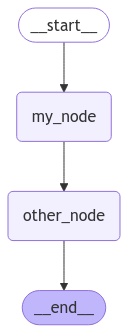

In [12]:
visualize_graph(graph)

## 상태(State) 관리

- LangGraph는 상태 관리에 두 가지 주요 개념을 도입합니다: 상태 스키마(state schemas)와 리듀서(reducers)입니다.
- 상태 스키마는 각 그래프의 노드에 전달되는 객체의 타입을 정의합니다.
- 리듀서는 노드의 출력을 현재 상태에 어떻게 적용할지를 정의합니다. 예를 들어, 새로운 대화 응답을 대화 기록에 병합하거나 여러 에이전트 노드의 출력을 평균화하는 데 리듀서를 사용할 수 있습니다. 상태 필드를 리듀서 함수로 주석 처리함으로써, 애플리케이션을 통해 데이터가 어떻게 흐르는지 정확하게 제어할 수 있습니다.

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START, StateGraph

### 예시1: StateA

In [14]:
class StateA(TypedDict):                  #TypeDict은 dictionary의 규격을 정할 수 있다.
    value: int                            #StateA는 TypeDict을 상속 받아 state의 dict을 정의 : {'value': 변수(int형)}

builder = StateGraph(StateA)
builder.add_node("my_node", lambda state: {"value": 1})     #state이름의 변수로 받아서 {"value":1}일 dict을 return한다.
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
graph = builder.compile()
graph.invoke({"value": 5})

{'value': 1}

In [26]:
class StateA2(TypedDict):
    jaeil : float

builder2 = StateGraph(StateA2)
builder2.add_node("mul2", lambda state2: {'jaeil' : state2['jaeil']*2})
builder2.add_node("div2",lambda state2: {"jaeil" : state2['jaeil']/2})
builder2.add_edge(START,"mul2")
builder2.add_edge("mul2","div2")
builder2.add_edge('div2',END)
graph2 = builder2.compile()
graph2.invoke({'jaeil': 1.0})

{'jaeil': 1.0}

In [15]:
#lambda 함수 이해하기
def kkk(x):
    print(x+3)

kkk(3)

6


In [19]:
a = lambda x:x+3

a(3)

6

### 예시 2: StateB

In [37]:
# reducer
def add(existing: int, new: int):
    return existing + new


class StateB(TypedDict):
    value: Annotated[int, add]


builder = StateGraph(StateB)
builder.add_node("my_node", lambda state: {"value": 1})
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
graph = builder.compile()
graph.invoke({"value": 5})

{'value': 6}

In [18]:
#1. State 정의하기(node간에 주고받는 변수)
class name(TypedDict): 
    input : str        #dict 이고 key는 input, data type str
    seq : int          #dict 이고 key는 seq, data type int

#2. node 정의하기(각 node에서 실핼될 함수)
def Firstname(state):
    first_name = state['input'] + '최'
    first_seq = state['seq'] + 1
    return {'input':first_name, 'seq':first_seq}

def Lastname(state):
    last_name = state['input'] + '재일'
    last_seq = state['seq'] + 1
    return {'input':last_name, 'seq':last_seq}

#3. graph state 선언하기
graph = StateGraph(name)

#4. graph node 선언하기
graph.add_node("Firstname",Firstname)
graph.add_node('Lastname',Lastname)

#5. graph edge 설정하기
graph.add_edge(START,"Firstname")
graph.add_edge("Firstname","Lastname")
graph.add_edge("Lastname",END)

#6. graph compile 하기
compile = graph.compile()

#7. graph invoke하기
compile.invoke({'input':"내 이름은 ", 'seq':0})

{'input': '내 이름은 최재일', 'seq': 2}

In [160]:
#1. State 정의하기(node간에 주고받는 변수)
class name(TypedDict):
    my_name : str
    #Annotated 함수이 받는 첫번째 변수는 기존 state에서 전달한 변수, 두번째 변수는 현재 state에서 return한 변수이다.
    seq : Annotated[int,add]

#2. node 정의하기(각 node에서 실핼될 함수)
def hello(state):
    name = state['my_name'] + ' hello'
    return {'my_name':name,'seq':state['seq']}

def add(bef:int,pre:int) -> int:
    return bef+pre+1

#3. graph state 선언하기
builder = StateGraph(name)

#4. graph node 선언하기
builder.add_node("First",hello)
builder.add_node("Second",hello)

#5. graph edge 선언하기
builder.add_edge(START,"First")
builder.add_edge("First","Second")
builder.add_edge("Second",END)

#6. graph compile하기
graph = builder.compile()

#7. graph invoke하기
graph.invoke({'my_name':'최재일', 'seq':0})

#Flow
#0. 기존 state = 없음
#1  invoke -> First:{'my_name':'최재일','seq': add(기존 seq:0),{invoke:0)}) -> 'seq'=0+0+1 = 1}
#2. First -> Second:{'my_name':'최재일 hello','seq': add(기존 seq:1),(현재 seq:1)}) -> 'seq'=1+1+1 = 3}
#3. First -> Second:{'my_name':'최재일 hello hello','seq': add(기존 seq:3),(현재 seq:3)}) -> 'seq'=3+3+1 = 7}


{'my_name': '최재일 hello hello', 'seq': 7}

In [159]:
#1. State 정의하기(node간에 주고받는 변수)
class name(TypedDict):
    my_name : str
    #Annotated 함수이 받는 첫번째 변수는 기존 state에서 전달한 변수, 두번째 변수는 현재 state에서 return한 변수이다.
    seq : Annotated[int,add]

#2. node 정의하기(각 node에서 실핼될 함수)
def hello(state):
    return {'seq':0}

def add(bef:int,pre:int) -> int:
    return bef+pre+1

#3. graph state 선언하기
builder = StateGraph(name)

#4. graph node 선언하기
builder.add_node("First",hello)
builder.add_node("Second",hello)

#5. graph edge 선언하기
builder.add_edge(START,"First")
builder.add_edge("First","Second")
builder.add_edge("Second",END)

#6. graph compile하기
graph = builder.compile()

#7. graph invoke하기
graph.invoke({'my_name':'최재일', 'seq':0})

#Flow
#0. 기존 state = 없음
#1  invoke -> First:{'my_name':'최재일','seq': add(기존 seq:0),{invoke:0)}) -> 'seq'=0+0+1 = 1}
#2. First -> Second:{'my_name':'최재일','seq': add(기존 seq:1),(현재 seq:0)}) -> 'seq'=1+0+1 = 2}
#3. First -> Second:{'my_name':'최재일','seq': add(기존 seq:2),(현재 seq:0)}) -> 'seq'=2+0+1 = 3}

{'my_name': '최재일', 'seq': 3}

In [148]:
#1. State 정의하기(node간에 주고받는 변수)
class name(TypedDict):
    my_name : str
    #Annotated 함수이 받는 첫번째 변수는 기존 state에서 전달한 변수, 두번째 변수는 현재 state에서 return한 변수이다.
    seq : Annotated[int,add]

#2. node 정의하기(각 node에서 실핼될 함수)
def hello(state):
    return {'seq':0}

def add(bef:int,pre:int) -> int:
    return bef+pre+1

#3. graph state 선언하기
builder = StateGraph(name)

#4. graph node 선언하기
builder.add_node("First",hello)
builder.add_node("Second",hello)

#5. graph edge 선언하기
builder.add_edge(START,"First")
builder.add_edge("First","Second")
builder.add_edge("Second",END)

#6. graph compile하기
graph = builder.compile()

#7. graph invoke하기
graph.invoke({'my_name':'최재일', 'seq':0})

#Flow
#1. START -> First : {'my_name':최재일,'seq': add(bef(0),{0}) -> 'seq'=0+{0}+1 = 1}
#2. First -> Second : {'my_name':'최재일', 'seq': add(1,{}) -> 'seq' = 1+{0}+1 = 2 }
#3. Second -> END : {'my_name':'최재일','seq': add({},{}) -> 'seq' = {2}+{0}+1 = 3}

{'my_name': '최재일', 'seq': 3}

In [19]:
# reducer
def add(existing: int, new: int):
    print('최재일')
    print('existing :',existing)
    print('new :',new)
    return existing + new


class StateB(TypedDict):
    value: Annotated[int, add]


builder = StateGraph(StateB)
builder.add_node("my_node", lambda state: {"value": 1})
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
graph = builder.compile()
graph.invoke({"value": 5}) #reducer(함수)는 invoke와 각 node 후에 실행된다.

최재일
existing : 0
new : 5
최재일
existing : 5
new : 1


{'value': 6}

In [46]:
# reducer
def add(new: int, existing: int):
    print('최재일')
    print('existing :',existing)
    print('new :',new)
    return existing + new


class StateB(TypedDict):
    value: Annotated[int, add]


builder = StateGraph(StateB)
builder.add_node("my_node", lambda state: {"value": 1})
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
graph = builder.compile()
graph.invoke({"value": 5}) #reducer(함수)는 invoke와 각 node 후에 실행된다.

최재일
existing : 5
new : 0
최재일
existing : 1
new : 5


{'value': 6}

1. Annotated는 node 출력을 다음 node에 전달할 때 중간에 처리하기 위해서 쓰인다.
2. Annotated[전달하는 변수 type, 함수명]로 정의한다.
3. Annotated 함수이 받는 첫번째 변수는 기존 state에서 전달한 변수, 두번째 변수는 현재 state에서 return한 변수이다.
4. 다음 node에 전달되는 변수는 Annotate 함수의 return값이다.

In [50]:
#state값 str
#Annotate 함수(기존 node의 str값 출력하고 더하기)

def print_add(history:str,present:str):
    print(history)
    print(present)
    return(history+present)


class State_CJI(TypedDict):
    value: Annotated[str, print_add]

def my_node(state):
    print(f"안녕하세요? 도와드릴까요?")
    x = {'value': f"{state['value']}에 대해 검색하겠습니다."}
    return x


builder = StateGraph(State_CJI)
builder.add_node("my_node",my_node)
builder.add_edge(START,"my_node")
builder.add_edge("my_node",END)
cji = builder.compile()
cji.invoke({"value":'HBM'})


HBM
안녕하세요? 도와드릴까요?
HBM
HBM에 대해 검색하겠습니다.


{'value': 'HBMHBM에 대해 검색하겠습니다.'}

보통 그래프의 상태 스키마(state_schema, 즉 State)로 TypedDict를 사용하지만, 상태 스키마는 거의 모든 타입이 될 수 있습니다. 따라서 다음과 같은 그래프도 완전히 유효합니다.

In [41]:
# Analogous to StateA above
builder = StateGraph(int)
builder.add_node("my_node", lambda state: 1)
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
builder.compile().invoke(5)

1

In [47]:
# Analogous to StateB
def add(left, right):
    print(left)
    print(right)
    return left + right


builder = StateGraph(Annotated[int, add])
builder.add_node("my_node", lambda state: 1)
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
graph = builder.compile()
graph.invoke(5)

0
5
5
1


6

## Configuration, Thread, Checkpoint

- Configuration
  - 어떤 그래프 배포에서도 런타임 시 제어할 수 있는 일부 구성 가능한 값을 원할 가능성이 높습니다. 이러한 값은 상태 변수로 취급되지 않으며, 그래프 입력과 다릅니다. 일반적인 예로는 대화의 thread_id, user_id, 사용할 LLM의 선택, 검색기에서 반환할 문서 수 등이 있습니다. 이러한 값을 상태 내에 전달할 수도 있지만, 정규 데이터 흐름과 분리하는 것이 더 좋습니다.
- Thread (스레드)
  - LangGraph의 Thread는 그래프의 개별 세션을 나타냅니다. 이러한 Thread는 애플리케이션에서 다중 대화와 다중 사용자 지원을 용이하게 하기 위해 개별 세션 내에서 상태 체크포인트를 구성합니다.
- Checkpoint (체크포인트)
  - 체크포인트는 애플리케이션과 사용자(또는 다른 사용자나 시스템) 간의 다중 턴 상호작용에서 스레드의 상태를 나타냅니다. 단일 실행 내에서 생성된 체크포인트는 이 상태에서 시작할 때 실행될 다음 노드 집합을 갖게 됩니다. 특정 실행이 끝날 때 생성된 체크포인트도 동일하지만, 전환할 다음 노드가 없다는 점이 다릅니다(그래프는 사용자 입력을 기다리고 있습니다).

In [41]:
def add(left, right):
    return left + right


class State(TypedDict):
    total: Annotated[int, add]
    turn: str


builder = StateGraph(State)
builder.add_node("add_one", lambda x: {"total": 1})
builder.add_edge(START, "add_one")
builder.add_edge("add_one", END)
graph = builder.compile()
graph.invoke({"total":2,"turn":'최재일'})

{'total': 3, 'turn': '최재일'}

In [162]:
from langgraph.checkpoint.memory import MemorySaver

def add(left, right):
    return left + right

class State(TypedDict):
    total: Annotated[int, add]
    turn: str


builder = StateGraph(State)
builder.add_node("add_one", lambda x: {"total": 1})
builder.add_edge(START, "add_one")
builder.add_edge("add_one", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

thread_id = "some-thread"
config = {"configurable": {"thread_id": thread_id}}

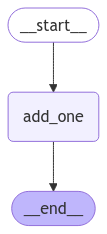

In [151]:
visualize_graph(graph)

In [152]:
thread_id = "some-thread"
config = {"configurable": {"thread_id": thread_id}}

In [153]:
result = graph.invoke({"total": 1, "turn": "First Turn"}, config)
result
#Flow
#0. 'thread_id'가 처음 선언(기존 state = 없음)
#1  invoke -> add_one:{'turn':'First Turn','total': add(기존 total값:0),{invoke:1)}) -> 'total'=0+1 = 1}
#2. add_one -> :{'turn':'First Turn','total': add(기존 total값:1),{현재node total:1)}) -> 'total'=1+1 = 2})

{'total': 2, 'turn': 'First Turn'}

In [154]:
result2 = graph.invoke({"turn": "Next Turn"}, config)
result2

#Flow
#0. 'thread_id'가 변경되지 않아 기존 state를 기억한다.(기존 state = {'total': 2, 'turn': 'First Turn'})
#1  invoke -> add_one:{'turn':'Next Turn','total': add(기존 total값:2),{invoke:0)}) -> 'total'=2+0 = 2}
#2. add_one -> :{'turn':'Next Turn','total': add(기존 total값:2),{현재node total:1)}) -> 'total'=2+1 = 3})

{'total': 3, 'turn': 'Next Turn'}

In [155]:
result3 = graph.invoke({"total": 5}, config)
result3

#Flow
#0. 'thread_id'가 변경되지 않아 기존 state를 기억한다.(기존 state = {'total': 3, 'turn': 'Next Turn'})
#1  invoke -> add_one:{'turn':'Next Turn','total': add(기존 total값:3),{invoke total:5)}) -> 'total'=3+5 = 8}
#2. add_one -> :{'turn':'Next Turn','total': add(기존 total값:8),{현재 total:1)}) -> 'total'=8+1 = 9})

{'total': 9, 'turn': 'Next Turn'}

In [16]:
result4 = graph.invoke({"total": 5}, {"configurable": {"thread_id": "new-thread-id"}})
result4

#Flow
#0. 'thread_id'가 변경됨. state값 없음
#1  invoke -> add_one:{'total': add(기존 total값:0),{invoke total:5)}) -> 'total'=0+5 = 5}
#2. add_one -> :{'total': add(기존 total값:5),{현재 total:1)}) -> 'total'=5+1 = 6})

{'total': 6}

#### 설명

1. 첫 번째 실행에서는 체크포인트가 없었기 때문에 그래프는 원시 입력으로 실행되었습니다. "total" 값은 1에서 2로 증가했고, "turn"은 "첫 번째 턴"으로 설정되었습니다.
2. 두 번째 실행에서는 사용자가 "turn"을 업데이트했지만 "total" 값은 제공하지 않았습니다! 상태에서 로드하므로, 이전 결과가 "add_one" 노드에서 1씩 증가하고, "turn"은 사용자가 제공한 값으로 덮어씌워집니다.
3. 세 번째 실행에서는 "turn"이 사용자에 의해 덮어씌워지지 않았기 때문에 체크포인트에서 로드된 그대로 유지됩니다. "total"은 사용자가 제공한 값으로 증가하며, 이는 추가 기능에 의해 감소(즉, 기존 값을 업데이트하는 데 사용됨)됩니다.
4. 네 번째 실행에서는 새로운 스레드 ID를 사용하고 있으며, 체크포인트를 찾을 수 없기 때문에 결과는 사용자가 제공한 "total"에 1을 더한 값이 됩니다.

In [170]:
def print_info(**kwargs):
    print(type(kwargs))
    print(kwargs.items())
    for key, value in kwargs.items():
        print(f"{key}: {value}")

print_info(name="Alice", age=30)

<class 'dict'>
dict_items([('name', 'Alice'), ('age', 30)])
name: Alice
age: 30


In [171]:
graph = builder.compile()
result = graph.invoke({"total": 1, "turn": "First Turn"})
result2 = graph.invoke({**result, "turn": "Next Turn"})
result3 = graph.invoke({**result2, "total": result2["total"] + 5})
result4 = graph.invoke({"total": 5})

In [172]:
result

{'total': 2, 'turn': 'First Turn'}

In [165]:
result2

{'total': 3, 'turn': 'Next Turn'}

In [166]:
result3

{'total': 9, 'turn': 'Next Turn'}

In [167]:
result4

{'total': 6}